Lets see how else we can build models.

Some of the examples are from [Deep Learning with Python, Second Edition](https://www.manning.com/books/deep-learning-with-python-second-edition?a_aid=keras&a_bid=76564dff). 

## Different ways to build Keras models

Keras - easy to start with but also possible to provide deep dives for those who need it.  
NLP and Image Processing are such needs.  

### The Sequential model

**The `Sequential` class**

Thing to remember - Keras is API based.  
Sequential is a list of stacked layers - there lies its first limitation.
So:
1. Only feedforward models.
2. Only one input (not for example a text/picture and its metadata)
3. Only one output (not for example multiple regression/classification predictions for one data point)
4. Linear topology

In [2]:
%pip install tensorboard
%pip install tensorflow
%pip install setuptools

Note: you may need to restart the kernel to use updated packages.


  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl (351.2 MB)
Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [3]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

**Incrementally building a Sequential model**

Like in Python list!

In [ ]:
model = keras.Sequential()
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(10, activation="softmax"))

In [ ]:
model.weights

[]

Error - model is not built yet

**Calling a model for the first time to build it**

In [ ]:
model.build(input_shape=(None, 3))
model.weights

[<Variable path=sequential_2/dense_4/kernel, shape=(3, 64), dtype=float32, value=[[ 2.85224974e-01 -2.95802057e-02  1.42674655e-01 -5.09178638e-03
    1.38978928e-01 -2.84619659e-01 -5.51171750e-02 -1.97398856e-01
    9.64656472e-02 -1.69766575e-01 -2.72643656e-01  8.49734247e-02
    1.44517422e-01  3.82937491e-02 -2.58258581e-01  1.28689498e-01
   -6.94856197e-02 -2.58685648e-01  2.24061191e-01 -2.39604786e-01
    2.37335384e-01 -2.28651747e-01 -1.99568748e-01  1.25049651e-01
    8.82074833e-02 -9.27589387e-02 -1.58980832e-01  1.49842501e-02
    2.21771061e-01 -9.03530270e-02  2.67092466e-01 -1.33320168e-01
   -4.68594134e-02 -1.63493201e-01 -8.08780938e-02 -3.09486687e-02
   -1.85095698e-01 -2.81826496e-01  5.68307936e-02  2.53174782e-01
    1.04623437e-01  2.45219707e-01 -2.80911028e-01  1.34897441e-01
    1.51782662e-01  2.95396686e-01  1.94085628e-01  1.63539141e-01
    6.34531975e-02 -5.98233938e-02 -2.20395923e-01  2.21000373e-01
    5.21309376e-02  9.75154638e-02  1.42979950e-0

**The summary method**

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

**Naming models and layers with the `name` argument**

You can name every layer, model and so on.

In [ ]:
model = keras.Sequential(name="my_example_model")
model.add(layers.Dense(64, activation="relu", name="my_first_layer"))
model.add(layers.Dense(10, activation="softmax", name="my_last_layer"))
model.build((None, 3))
model.summary()

Model: "my_example_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_first_layer (Dense)          │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_last_layer (Dense)           │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

**Specifying the input shape of your model in advance**

With that you can see the summary without actually building the model

In [ ]:
model = keras.Sequential()
model.add(keras.Input(shape=(3,)))
model.add(layers.Dense(64, activation="relu"))

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 256 (1.00 KB)

 Trainable params: 256 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(layers.Dense(10, activation="softmax"))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

### The Functional API

#### A simple example

**A simple Functional model with two `Dense` layers**

In [ ]:
inputs = keras.Input(shape=(3,), name="my_input")
features = layers.Dense(64, activation="relu")(inputs)
outputs = layers.Dense(10, activation="softmax")(features)
model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
inputs = keras.Input(shape=(3,), name="my_input")

In [ ]:
inputs.shape

(None, 3)

In [ ]:
inputs.dtype

'float32'

This is what we did - add another layer on top of the previous one

In [ ]:
features = layers.Dense(64, activation="relu")(inputs)

In [ ]:
features.shape

(None, 64)

In [ ]:
outputs = layers.Dense(10, activation="softmax")(features)
model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_input (InputLayer)           │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

#### Multi-input, multi-output models

**A multi-input, multi-output Functional model**

Lets image a usecase of dealing with support tickets.  
We need to move tickets to appropriate departaments. What we know:  
1. Title of ticket (text)
2. Text of the ticket (text)
3. Tags added by the user (one-hot encoding)

We expect to know:
1. Priority of the ticket (regression)
2. Departament where to move the ticket (classification)

In [ ]:
vocabulary_size = 10000 #this is what we did on bert - how many words do we use from the dictionary
num_tags = 100
num_departments = 4

title = keras.Input(shape=(vocabulary_size,), name="title")
text_body = keras.Input(shape=(vocabulary_size,), name="text_body")
tags = keras.Input(shape=(num_tags,), name="tags")

features = layers.Concatenate()([title, text_body, tags])
features = layers.Dense(64, activation="relu")(features)

priority = layers.Dense(1, activation="sigmoid", name="priority")(features)
department = layers.Dense(
    num_departments, activation="softmax", name="department")(features)

model = keras.Model(inputs=[title, text_body, tags], outputs=[priority, department])

#### Training a multi-input, multi-output model

**Training a model by providing lists of input & target arrays**

In [ ]:
import numpy as np

num_samples = 1280

title_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
text_body_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
tags_data = np.random.randint(0, 2, size=(num_samples, num_tags))

priority_data = np.random.random(size=(num_samples, 1))
department_data = np.random.randint(0, 2, size=(num_samples, num_departments))

model.compile(optimizer="adam",
              loss=["mean_squared_error", "categorical_crossentropy"],
              metrics=[["mean_absolute_error"], ["accuracy"]])
model.fit([title_data, text_body_data, tags_data],
          [priority_data, department_data],
          epochs=1)
model.evaluate([title_data, text_body_data, tags_data],
               [priority_data, department_data])
priority_preds, department_preds = model.predict([title_data, text_body_data, tags_data])

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - department_accuracy: 0.2359 - department_loss: 10.6614 - loss: 10.9799 - priority_loss: 0.3185 - priority_mean_absolute_error: 0.4826
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - department_accuracy: 0.4820 - department_loss: 2.7779 - loss: 3.1042 - priority_loss: 0.3264 - priority_mean_absolute_error: 0.4914
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


**Training a model by providing dicts of input & target arrays**

Here we are using names - for complex models

In [ ]:
model.compile(optimizer="adam",
              loss={"priority": "mean_squared_error", "department": "categorical_crossentropy"},
              metrics={"priority": ["mean_absolute_error"], "department": ["accuracy"]})
model.fit({"title": title_data, "text_body": text_body_data, "tags": tags_data},
          {"priority": priority_data, "department": department_data},
          epochs=1)
model.evaluate({"title": title_data, "text_body": text_body_data, "tags": tags_data},
               {"priority": priority_data, "department": department_data})
priority_preds, department_preds = model.predict(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data})

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - department_accuracy: 0.3523 - department_loss: 4.5104 - loss: 4.8368 - priority_loss: 0.3264 - priority_mean_absolute_error: 0.4914
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - department_accuracy: 0.2812 - department_loss: 4.0795 - loss: 4.4059 - priority_loss: 0.3264 - priority_mean_absolute_error: 0.4914
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


#### The power of the Functional API: Access to layer connectivity

In [ ]:
keras.utils.plot_model(model, "ticket_classifier.png")

You must install pydot (`pip install pydot`) for `plot_model` to work.


![Plot Model](../img/plot-ticketmodel.png)

Source: https://www.manning.com/books/deep-learning-with-python  

This can mean retrieving fetures from another models and reusing components

**Retrieving the inputs or outputs of a layer in a Functional model**

In [ ]:
model.layers

[<InputLayer name=title, built=True>,
 <InputLayer name=text_body, built=True>,
 <InputLayer name=tags, built=True>,
 <Concatenate name=concatenate, built=True>,
 <Dense name=dense_12, built=True>,
 <Dense name=priority, built=True>,
 <Dense name=department, built=True>]

In [ ]:
model.layers[3].input

[<KerasTensor shape=(None, 10000), dtype=float32, sparse=False, ragged=False, name=title>,
 <KerasTensor shape=(None, 10000), dtype=float32, sparse=False, ragged=False, name=text_body>,
 <KerasTensor shape=(None, 100), dtype=float32, sparse=False, ragged=False, name=tags>]

In [ ]:
model.layers[3].output

<KerasTensor shape=(None, 20100), dtype=float32, sparse=False, ragged=False, name=keras_tensor_14>

**Creating a new model by reusing intermediate layer outputs**

Adding new prediction to the existing model. Easy! 
Now: 3 categories of difficulty resolving the ticket

In [ ]:
features = model.layers[4].output
difficulty = layers.Dense(3, activation="softmax", name="difficulty")(features)

new_model = keras.Model(
    inputs=[title, text_body, tags],
    outputs=[priority, department, difficulty])

In [ ]:
keras.utils.plot_model(new_model, "updated_ticket_classifier.png", show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


### Subclassing the Model class

#### Rewriting our previous example as a subclassed model

**A simple subclassed model**

You're in charge, you can write a call and init hovewer you like without the graph-like constraints of Functional API

In [ ]:
class CustomerTicketModel(keras.Model):

    def __init__(self, num_departments):
        super().__init__()
        self.concat_layer = layers.Concatenate()
        self.mixing_layer = layers.Dense(64, activation="relu")
        self.priority_scorer = layers.Dense(1, activation="sigmoid")
        self.department_classifier = layers.Dense(
            num_departments, activation="softmax")

    def call(self, inputs):
        title = inputs["title"]
        text_body = inputs["text_body"]
        tags = inputs["tags"]

        features = self.concat_layer([title, text_body, tags])
        features = self.mixing_layer(features)
        priority = self.priority_scorer(features)
        department = self.department_classifier(features)
        return priority, department

In [ ]:
model = CustomerTicketModel(num_departments=4)

priority, department = model(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data})

In [ ]:
model.compile(optimizer="adam",
              loss=["mean_squared_error", "categorical_crossentropy"],
              metrics=[["mean_absolute_error"], ["accuracy"]])
model.fit({"title": title_data,
           "text_body": text_body_data,
           "tags": tags_data},
          [priority_data, department_data],
          epochs=1)
model.evaluate({"title": title_data,
                "text_body": text_body_data,
                "tags": tags_data},
               [priority_data, department_data])
priority_preds, department_preds = model.predict({"title": title_data,
                                                  "text_body": text_body_data,
                                                  "tags": tags_data})

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2656 - categorical_crossentropy_loss: 8.1517 - loss: 8.4733 - mean_absolute_error: 0.4861 - mean_squared_error_loss: 0.3216  
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1391 - categorical_crossentropy_loss: 3.2908 - loss: 3.6172 - mean_absolute_error: 0.4914 - mean_squared_error_loss: 0.3264
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


#### Beware: What subclassed models don't support

This is your Python code.  
You cannot:
1. Use summary()
2. Use plot_model()
3. Just snap pieces together - this is your model with potencially more room for mistakes and debugging issues.

### Mixing and matching different components

**Creating a Functional model that includes a subclassed model**

A Subclass in Functional Model, A Funtional Model inside a Subclass

In [ ]:
class Classifier(keras.Model):

    def __init__(self, num_classes=2):
        super().__init__()
        if num_classes == 2:
            num_units = 1
            activation = "sigmoid"
        else:
            num_units = num_classes
            activation = "softmax"
        self.dense = layers.Dense(num_units, activation=activation)

    def call(self, inputs):
        return self.dense(inputs)

inputs = keras.Input(shape=(3,))
features = layers.Dense(64, activation="relu")(inputs)
outputs = Classifier(num_classes=10)(features)
model = keras.Model(inputs=inputs, outputs=outputs)

**Creating a subclassed model that includes a Functional model**

In [ ]:
inputs = keras.Input(shape=(64,))
outputs = layers.Dense(1, activation="sigmoid")(inputs)
binary_classifier = keras.Model(inputs=inputs, outputs=outputs)

class MyModel(keras.Model):

    def __init__(self, num_classes=2):
        super().__init__()
        self.dense = layers.Dense(64, activation="relu")
        self.classifier = binary_classifier

    def call(self, inputs):
        features = self.dense(inputs)
        return self.classifier(features)

model = MyModel()

### Remember: Use the right tool for the job

In Keras, there is a spectrum of ways to build models — from the simplest approach (Sequential models) to the most flexible one (model subclassing).

There is no single “correct” choice.  
Each approach has advantages and limitations, and the right one depends on the problem you are solving.

In most practical situations, the **Functional API** offers the best balance between clarity and flexibility. It allows you to explicitly define how layers are connected, which makes your model structure transparent and easy to analyze. This becomes particularly useful when you want to visualize the architecture, inspect intermediate outputs, or extract features.

If your model can be represented as a directed acyclic graph of layers — which is true for most standard deep learning architectures — the Functional API is usually the recommended choice over full model subclassing.

Throughout our work, we will primarily use the Functional API, because the models we study can be naturally expressed as graphs of layers. At the same time, we will often create custom (subclassed) layers when needed.

In practice, combining Functional models with subclassed layers gives you both structure and flexibility — a clear architecture with the ability to customize internal behavior when necessary.

## Using built-in training and evaluation loops

**The standard workflow: `compile()`, `fit()`, `evaluate()`, `predict()`**

In [4]:
from tensorflow.keras.datasets import mnist

def get_mnist_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = keras.Model(inputs, outputs)
    return model

(images, labels), (test_images, test_labels) = mnist.load_data()
images = images.reshape((60000, 28 * 28)).astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255
train_images, val_images = images[10000:], images[:10000]
train_labels, val_labels = labels[10000:], labels[:10000]

model = get_mnist_model()
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.fit(train_images, train_labels,
          epochs=3,
          validation_data=(val_images, val_labels))
test_metrics = model.evaluate(test_images, test_labels)
predictions = model.predict(test_images)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9122 - loss: 0.2913 - val_accuracy: 0.9560 - val_loss: 0.1472
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9544 - loss: 0.1482 - val_accuracy: 0.9694 - val_loss: 0.1026
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9649 - loss: 0.1153 - val_accuracy: 0.9725 - val_loss: 0.0912
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9740 - loss: 0.0830
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


### Writing your own metrics

**Implementing a custom metric by subclassing the `Metric` class**

In [ ]:
import tensorflow as tf

class RootMeanSquaredError(keras.metrics.Metric):

    def __init__(self, name="rmse", **kwargs):
        super().__init__(name=name, **kwargs)
        self.mse_sum = self.add_weight(name="mse_sum", initializer="zeros")
        self.total_samples = self.add_weight(
            name="total_samples", initializer="zeros", dtype="int32")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.one_hot(y_true, depth=tf.shape(y_pred)[1])
        mse = tf.reduce_sum(tf.square(y_true - y_pred))
        self.mse_sum.assign_add(mse)
        num_samples = tf.shape(y_pred)[0]
        self.total_samples.assign_add(num_samples)

    def result(self):
        return tf.sqrt(self.mse_sum / tf.cast(self.total_samples, tf.float32))

    def reset_state(self):
        self.mse_sum.assign(0.)
        self.total_samples.assign(0)

In [ ]:
model = get_mnist_model()
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy", RootMeanSquaredError()])
model.fit(train_images, train_labels,
          epochs=3,
          validation_data=(val_images, val_labels))
test_metrics = model.evaluate(test_images, test_labels)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9141 - loss: 0.2903 - rmse: 0.3607 - val_accuracy: 0.9617 - val_loss: 0.1337 - val_rmse: 0.2441
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9551 - loss: 0.1478 - rmse: 0.2616 - val_accuracy: 0.9711 - val_loss: 0.0967 - val_rmse: 0.2098
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9643 - loss: 0.1137 - rmse: 0.2321 - val_accuracy: 0.9723 - val_loss: 0.0912 - val_rmse: 0.2051
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9736 - loss: 0.0819 - rmse: 0.1973


### Using callbacks

#### The EarlyStopping and ModelCheckpoint callbacks

Callbacks are mechanisms that allow us to intervene in the training process.
They are executed at specific moments during training (for example, at the end of each epoch).

Instead of letting training run blindly, callbacks allow us to monitor, adjust, and control it.

Below are common use cases.

**Model Checkpointing**

Saves the state of the model during training.

This allows you to:
- Keep the best-performing model
- Resume training later
- Avoid losing progress if training is interrupted

Keras implementation:
keras.callbacks.ModelCheckpoint

**Early Stopping**

Stops training when the validation metric (usually validation loss) stops improving.

This helps prevent overfitting.
It also ensures that the model parameters correspond to the best validation performance.

Keras implementation:
keras.callbacks.EarlyStopping

**Learning Rate Scheduling**

Adjusts the learning rate during training.

This can:
- Speed up convergence
- Stabilize training
- Help escape plateaus

Two common options:

keras.callbacks.LearningRateScheduler  
→ manually defines how the learning rate changes

keras.callbacks.ReduceLROnPlateau  
→ automatically reduces learning rate when validation performance stops improving

**Logging and Monitoring**

Records training and validation metrics during training.

This allows:
- Tracking performance over time
- Plotting learning curves
- Diagnosing instability

keras.callbacks.CSVLogger  
→ saves metrics to a file

Even the training progress bar in model.fit() is implemented as a callback.

In practice, combining EarlyStopping and ModelCheckpoint is common and recommended.

**Using the `callbacks` argument in the `fit()` method**

In [ ]:
callbacks_list = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=2,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="checkpoint_path.keras",
        monitor="val_loss",
        save_best_only=True,
    )
]
model = get_mnist_model()
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.fit(train_images, train_labels,
          epochs=10,
          callbacks=callbacks_list,
          validation_data=(val_images, val_labels))

NameError: name 'get_mnist_model' is not defined

In [ ]:
model = keras.models.load_model("checkpoint_path.keras")

### Writing your own callbacks

**Creating a custom callback by subclassing the `Callback` class**

In [ ]:
from matplotlib import pyplot as plt

class LossHistory(keras.callbacks.Callback):
    def on_train_begin(self, logs):
        self.per_batch_losses = []

    def on_batch_end(self, batch, logs):
        self.per_batch_losses.append(logs.get("loss"))

    def on_epoch_end(self, epoch, logs):
        plt.clf()
        plt.plot(range(len(self.per_batch_losses)), self.per_batch_losses,
                 label="Training loss for each batch")
        plt.xlabel(f"Batch (epoch {epoch})")
        plt.ylabel("Loss")
        plt.legend()
        plt.savefig(f"plot_at_epoch_{epoch}")
        self.per_batch_losses = []

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9125 - loss: 0.2934 - val_accuracy: 0.9582 - val_loss: 0.1417
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9544 - loss: 0.1564 - val_accuracy: 0.9680 - val_loss: 0.1111
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9623 - loss: 0.1286 - val_accuracy: 0.9744 - val_loss: 0.0952
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9694 - loss: 0.1096 - val_accuracy: 0.9747 - val_loss: 0.0965
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9714 - loss: 0.1023 - val_accuracy: 0.9759 - val_loss: 0.0956
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9738 - loss: 0.0967 - val_accuracy: 0.9778 - val_loss: 0.0899
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9763 - loss: 0.0870 - val_accuracy: 0.9789 - val_loss: 0.0867
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9777 - loss: 0

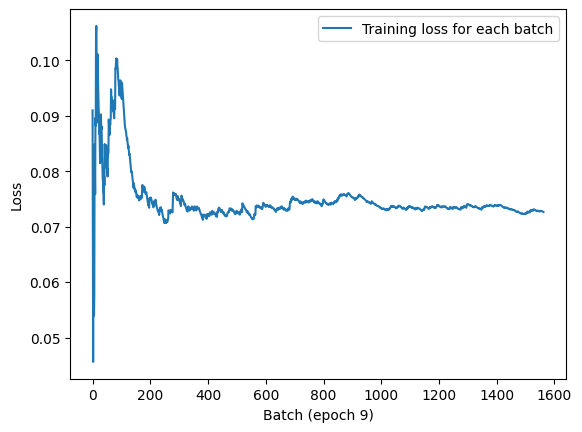

In [ ]:
model = get_mnist_model()
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.fit(train_images, train_labels,
          epochs=10,
          callbacks=[LossHistory()],
          validation_data=(val_images, val_labels))

### Monitoring and visualization with TensorBoard

TensorBoard is a browser-based application that you can run locally. It’s the best way to monitor everything that goes on inside your model during training. With TensorBoard, you can

1. Visually monitor metrics during training
2. Visualize your model architecture
3. Visualize histograms of activations and gradients
4. Explore embeddings in 3D
5. If you’re monitoring more information than just the model’s final loss, you can develop a clearer vision of what the model does and doesn’t do, and you can make progress more quickly.

The easiest way to use TensorBoard with a Keras model and the fit() method is the keras.callbacks.TensorBoard callback. In the simplest case, just specify where you want the callback to write logs.

In [5]:
import tensorflow as tf
import tensorboard
import setuptools
print(tf.__version__)
print(tensorboard.__version__)
print(setuptools.__version__)

2.21.0
2.20.0
82.0.1


In [6]:
model = get_mnist_model()
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

tensorboard = keras.callbacks.TensorBoard(
    log_dir="/full_path_to_your_log_dir",
     write_graph=True
)
model.fit(train_images, train_labels,
          epochs=3,
          validation_data=(val_images, val_labels),
          callbacks=[tensorboard])

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9111 - loss: 0.2906 - val_accuracy: 0.9607 - val_loss: 0.1326
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9553 - loss: 0.1480 - val_accuracy: 0.9675 - val_loss: 0.1044
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9646 - loss: 0.1132 - val_accuracy: 0.9719 - val_loss: 0.0948


In [7]:
%reload_ext tensorboard

In [9]:
%tensorboard --logdir /full_path_to_your_log_dir

Reusing TensorBoard on port 6006 (pid 27704), started 0:28:52 ago. (Use '!kill 27704' to kill it.)

More on how to use tensorboard here: https://www.tensorflow.org/tensorboard/get_started

## Writing your own training and evaluation loops

### Training versus inference

### Low-level usage of metrics

In [ ]:
metric = keras.metrics.SparseCategoricalAccuracy()
targets = [0, 1, 2]
predictions = [[1, 0, 0], [0, 1, 0], [0, 0, 1]]
metric.update_state(targets, predictions)
current_result = metric.result()
print(f"result: {current_result:.2f}")

result: 1.00


In [ ]:
values = [0, 1, 2, 3, 4]
mean_tracker = keras.metrics.Mean()
for value in values:
    mean_tracker.update_state(value)
print(f"Mean of values: {mean_tracker.result():.2f}")

Mean of values: 2.00


### A complete training and evaluation loop

**Writing a step-by-step training loop: the training step function**

In [ ]:
model = get_mnist_model()

loss_fn = keras.losses.SparseCategoricalCrossentropy()
optimizer = keras.optimizers.RMSprop()
metrics = [keras.metrics.SparseCategoricalAccuracy()]
loss_tracking_metric = keras.metrics.Mean()

def train_step(inputs, targets):
    with tf.GradientTape() as tape:
        predictions = model(inputs, training=True)
        loss = loss_fn(targets, predictions)
    gradients = tape.gradient(loss, model.trainable_weights)
    optimizer.apply_gradients(zip(gradients, model.trainable_weights))

    logs = {}
    for metric in metrics:
        metric.update_state(targets, predictions)
        logs[metric.name] = metric.result()

    loss_tracking_metric.update_state(loss)
    logs["loss"] = loss_tracking_metric.result()
    return logs

**Writing a step-by-step training loop: resetting the metrics**

In [ ]:
def reset_metrics():
    for metric in metrics:
        metric.reset_state()
    loss_tracking_metric.reset_state()

**Writing a step-by-step training loop: the loop itself**

In [ ]:
training_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
training_dataset = training_dataset.batch(32)
epochs = 3
for epoch in range(epochs):
    reset_metrics()
    for inputs_batch, targets_batch in training_dataset:
        logs = train_step(inputs_batch, targets_batch)
    print(f"Results at the end of epoch {epoch}")
    for key, value in logs.items():
        print(f"...{key}: {value:.4f}")

Results at the end of epoch 0
...sparse_categorical_accuracy: 0.9141
...loss: 0.2877
Results at the end of epoch 1
...sparse_categorical_accuracy: 0.9542
...loss: 0.1589


KeyboardInterrupt: 

**Writing a step-by-step evaluation loop**

In [ ]:
def test_step(inputs, targets):
    predictions = model(inputs, training=False)
    loss = loss_fn(targets, predictions)

    logs = {}
    for metric in metrics:
        metric.update_state(targets, predictions)
        logs["val_" + metric.name] = metric.result()

    loss_tracking_metric.update_state(loss)
    logs["val_loss"] = loss_tracking_metric.result()
    return logs

val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
val_dataset = val_dataset.batch(32)
reset_metrics()
for inputs_batch, targets_batch in val_dataset:
    logs = test_step(inputs_batch, targets_batch)
print("Evaluation results:")
for key, value in logs.items():
    print(f"...{key}: {value:.4f}")

### Leveraging fit() with a custom training loop

**Implementing a custom training step to use with `fit()`**

In [ ]:
loss_fn = keras.losses.SparseCategoricalCrossentropy()
loss_tracker = keras.metrics.Mean(name="loss")

class CustomModel(keras.Model):
    def train_step(self, data):
        inputs, targets = data
        with tf.GradientTape() as tape:
            predictions = self(inputs, training=True)
            loss = loss_fn(targets, predictions)
        gradients = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))

        loss_tracker.update_state(loss)
        return {"loss": loss_tracker.result()}

    @property
    def metrics(self):
        return [loss_tracker]

In [ ]:
inputs = keras.Input(shape=(28 * 28,))
features = layers.Dense(512, activation="relu")(inputs)
features = layers.Dropout(0.5)(features)
outputs = layers.Dense(10, activation="softmax")(features)
model = CustomModel(inputs, outputs)

model.compile(optimizer=keras.optimizers.RMSprop())
model.fit(train_images, train_labels, epochs=3)

In [ ]:
class CustomModel(keras.Model):
    def train_step(self, data):
        inputs, targets = data
        with tf.GradientTape() as tape:
            predictions = self(inputs, training=True)
            loss = self.compiled_loss(targets, predictions)
        gradients = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))
        self.compiled_metrics.update_state(targets, predictions)
        return {m.name: m.result() for m in self.metrics}

In [ ]:
inputs = keras.Input(shape=(28 * 28,))
features = layers.Dense(512, activation="relu")(inputs)
features = layers.Dropout(0.5)(features)
outputs = layers.Dense(10, activation="softmax")(features)
model = CustomModel(inputs, outputs)

model.compile(optimizer=keras.optimizers.RMSprop(),
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=[keras.metrics.SparseCategoricalAccuracy()])
model.fit(train_images, train_labels, epochs=3)